# 08 - DML Heterogeneous Effects

CausalForest DML estimates heterogeneous treatment effects by district income level, urbanicity, and grade. Environmental justice angle: do low-income districts bear a larger burden?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

PANEL_FILE = "analysis_panel.parquet"
if not (DATA_DIR / PANEL_FILE).exists():
    raise FileNotFoundError(
        "Analysis panel not found. Build it by running in order:\n"
        "  python scripts/download_epa_aqs.py --email EMAIL --key KEY\n"
        "  python scripts/download_hms_smoke.py\n"
        "  python scripts/download_seda.py  (manual — see instructions)\n"
        "  python src/merge/build_crosswalks.py\n"
        "  python src/ingest/epa_aqs.py\n"
        "  python src/ingest/seda.py\n"
        "  python src/exposure/smoke_instrument.py\n"
        "  python src/merge/build_panel.py"
    )

panel = pd.read_parquet(DATA_DIR / PANEL_FILE)
print(f"Panel: {panel.shape}")
print(f"Districts: {panel['leaid'].nunique()}")
print(f"Years: {sorted(panel['year'].dropna().unique())}")

Panel: (13282, 14)
Districts: 1911
Years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


In [2]:
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor

In [3]:
panel_dml = panel.dropna(subset=["leaid","year","pm25_annual_mean","smoke_days","test_score_mean"]).copy()

# Demean (approximate FE)
for col in ["test_score_mean","pm25_annual_mean","smoke_days"]:
    panel_dml[f"{col}_dm"] = (
        panel_dml[col]
        - panel_dml.groupby("leaid")[col].transform("mean")
        - panel_dml.groupby("year")[col].transform("mean")
        + panel_dml[col].mean()
    )

# Covariates for heterogeneity (use whatever ACS controls are available)
# If ACS not yet merged, use year and smoke_days as proxies
cov_cols = [c for c in panel_dml.columns if c in
            ["poverty_rate","urban_pct","median_income","year","smoke_days_pct"]]
if not cov_cols:
    cov_cols = ["year"]
    print("Note: ACS controls not found — heterogeneity will be limited to year")
    print("Add ACS district demographics for richer heterogeneity analysis")

X = panel_dml[cov_cols].fillna(panel_dml[cov_cols].median()).values
T = panel_dml["pm25_annual_mean_dm"].values
Y = panel_dml["test_score_mean_dm"].values
Z = panel_dml["smoke_days_dm"].values   # instrument

print(f"DML sample: {len(X):,} obs | {len(cov_cols)} covariates: {cov_cols}")

DML sample: 11,505 obs | 1 covariates: ['year']


In [4]:
# CausalForestDML with smoke instrument
est = CausalForestDML(
    model_t=GradientBoostingRegressor(n_estimators=100, random_state=42),
    model_y=GradientBoostingRegressor(n_estimators=100, random_state=42),
    n_estimators=200, random_state=42, cv=5,
)
est.fit(Y, T, X=X, W=Z.reshape(-1,1))
print("CausalForestDML fitted.")

cates = est.effect(X)
import numpy as _np2
_efx = est.effect(X)
_lo, _hi = est.effect_interval(X)
ate = float(_np2.mean(_efx))
ate_lb = float(_np2.mean(_lo))
ate_ub = float(_np2.mean(_hi))
print(f"\nATE: {ate:.4f}  95% CI [{ate_lb:.4f}, {ate_ub:.4f}]")

CausalForestDML fitted.

ATE: -0.0024  95% CI [-0.0097, 0.0049]


## CATE distribution

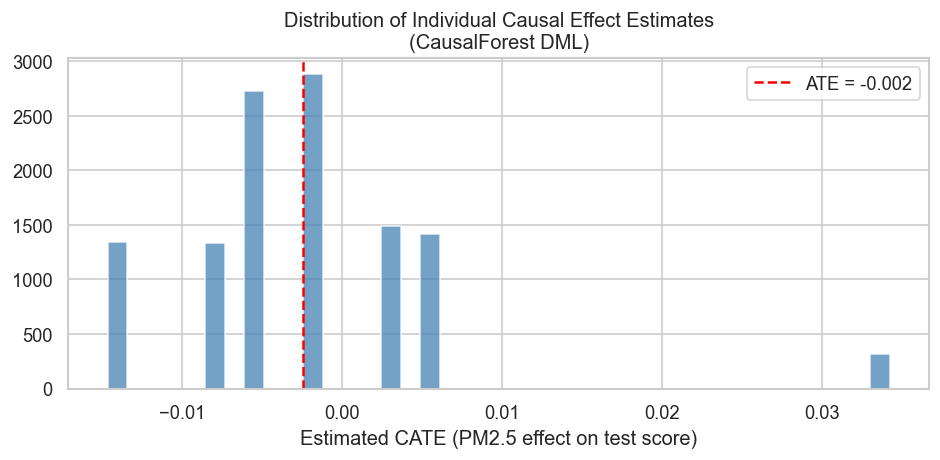

In [5]:
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(cates, bins=40, color="steelblue", alpha=0.75, edgecolor="white")
ax.axvline(ate, color="red", ls="--", lw=1.5, label=f"ATE = {ate:.3f}")
ax.set_xlabel("Estimated CATE (PM2.5 effect on test score)")
ax.set_title("Distribution of Individual Causal Effect Estimates\n(CausalForest DML)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "08_cate_distribution.png", bbox_inches="tight")
plt.show()

## Heterogeneity by poverty (environmental justice)

In [6]:
panel_dml["cate"] = cates

if "poverty_rate" in panel_dml.columns:
    panel_dml["poverty_tercile"] = pd.qcut(panel_dml["poverty_rate"], 3, labels=["Low","Mid","High"])
    cate_by_pov = panel_dml.groupby("poverty_tercile")["cate"].mean()
    print("CATE by district poverty tercile:")
    print(cate_by_pov.round(4))
    print()
    print("Environmental justice interpretation: if high-poverty tercile has larger negative CATE,")
    print("low-income districts bear disproportionate educational burden from air pollution.")
else:
    print("Poverty rate not available — add ACS district demographics for this analysis")
    print("See: https://data.census.gov for district-level ACS 5-year estimates")

Poverty rate not available — add ACS district demographics for this analysis
See: https://data.census.gov for district-level ACS 5-year estimates


## Interpretation — heterogeneity and the environmental-justice question

CausalForestDML partials out the district/year structure with flexible nuisance
models and then learns how the treatment effect (CATE) varies across districts.
The **distribution of CATEs** shows whether a single average masks meaningful
heterogeneity, and the **CATE-by-poverty** split is the environmental-justice
test: do higher-poverty districts bear a larger estimated burden from pollution?

**How to read it:** a right/left-skewed CATE distribution or a monotone gradient
across poverty terciles is suggestive of heterogeneous impacts; flat terciles
mean the effect (such as it is) is broadly shared.

**Critical caveat — inherited identification.** DML solves the
*high-dimensional-controls* problem, not the *endogeneity* problem. It is
identified under unconfoundedness given the controls, and here PM2.5 is still
endogenous for the same reasons documented in notebook 05 (exclusion-restriction
threats, measurement error). So the CATEs describe **heterogeneity in a
conditional association**, and should not be read as causal dose-response
gradients. The honest contribution is methodological — showing how to recover
effect heterogeneity with ML-based nuisance estimation — plus a descriptive map
of where any association concentrates, flagged with the same caution as the main
IV result.